[LangChain RAG Tutorial](https://python.langchain.com/docs/tutorials/rag/)  
[LangGraph Agentic RAG Tutorial](https://langchain-ai.github.io/langgraph/tutorials/rag/langgraph_agentic_rag/#7-assemble-the-graph)

# 1. Preparar documentos

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Carga attendance_docs_enriched.json y genera:
  • docs        → list[Document]   (page_content + metadata)
  • custom_ids  → list[str]        (UUID original)
Sin dividir en chunks.
"""

import json
from pathlib import Path
from datetime import datetime
from langchain.docstore.document import Document
from langchain.document_loaders import JSONLoader

# Ruta al JSON enriquecido
JSON_PATH = Path("../data/attendance_docs_enriched.json")

# 1️⃣ Cargar cada registro como Document
loader = JSONLoader(
    file_path=JSON_PATH,
    jq_schema=".[]",          # cada elemento del arreglo
    text_content=False        # page_content será la cadena JSON
)
docs_raw = loader.load()      # list[Document]

# 2️⃣ Normalización
def normalize(doc: Document) -> tuple[Document, str]:
    # Convertir page_content (str) → dict
    rec = json.loads(doc.page_content)

    # Texto que se embeddeará
    texto = (
        f"Asistencia del {rec['fecha_larga']} – {rec['legislatura']}.\n"
        f"Congreso {rec['periodo_congreso']} | "
        f"Periodo anual {rec['periodo_anual']}.\n"
        f"URL: {rec['url']}"
    )

    # Timestamp y desgloses para filtros
    dt = datetime.fromisoformat(rec["fecha"])
    fecha_ts = int(dt.timestamp() * 1000)  # milisegundos Unix

    metadata = {
        # Identificación
        "doc_id": rec["id"],
        "sesion": rec["sesion"],
        # Temporal
        "fecha_iso": rec["fecha"],
        "fecha_ts":  fecha_ts,
        "anio":      dt.year,
        "mes":       dt.month,
        "dia":       dt.day,
        "hora":      rec["hora"],
        "fecha_larga": rec["fecha_larga"],
        "fecha_corta": rec["fecha_corta"],
        # Legislatura / periodos
        "legislatura_txt": rec["legislatura"],
        "n_legislatura":   rec["n_legislatura"],
        "periodo_congreso_inicio": rec["periodo_congreso_inicio"],
        "periodo_congreso_fin":    rec["periodo_congreso_fin"],
        "periodo_anual_inicio":    rec["periodo_anual_inicio"],
        "periodo_anual_fin":       rec["periodo_anual_fin"],
        # Navegación
        "page": rec["page"],
        "url":  rec["url"],
        # Tipo de documento y versión
        "doctype": "attendance_header",
        "version": datetime.now().strftime("%Y.%m.%d.%H.%M"),
    }

    return Document(page_content=texto, metadata=metadata), rec["id"]

# 3️⃣ Procesar todos los registros
docs_and_ids = [normalize(d) for d in docs_raw]
docs        = [d for d, _ in docs_and_ids]
custom_ids  = [cid for _, cid in docs_and_ids]

# 4️⃣ Resumen
print(f"Documentos cargados : {len(docs)}")
print("Ejemplo de metadata :")
print(json.dumps(docs[0].metadata, indent=2, ensure_ascii=False))

Documentos cargados : 847
Ejemplo de metadata :
{
  "doc_id": "bff3a786-b7a3-4e81-9129-77734ad01ad1",
  "sesion": "937_pp2006_2011_pa2009_2010_leg1_page_13",
  "fecha_iso": "2009-10-07T15:38:00",
  "fecha_ts": 1254947880000,
  "anio": 2009,
  "mes": 10,
  "dia": 7,
  "hora": "15:38",
  "fecha_larga": "07 de octubre del 2009",
  "fecha_corta": "07 oct 2009",
  "legislatura_txt": "Primera Legislatura Ordinaria 2009-2010",
  "n_legislatura": 1,
  "periodo_congreso_inicio": 2006,
  "periodo_congreso_fin": 2011,
  "periodo_anual_inicio": 2009,
  "periodo_anual_fin": 2010,
  "page": 13,
  "url": "http://localhost:8080/asistencia/937_pp2006_2011_pa2009_2010_leg1_page_13.png",
  "doctype": "attendance_header",
  "version": "2025.09.01.16.03"
}


In [2]:
docs[0]


Document(metadata={'doc_id': 'bff3a786-b7a3-4e81-9129-77734ad01ad1', 'sesion': '937_pp2006_2011_pa2009_2010_leg1_page_13', 'fecha_iso': '2009-10-07T15:38:00', 'fecha_ts': 1254947880000, 'anio': 2009, 'mes': 10, 'dia': 7, 'hora': '15:38', 'fecha_larga': '07 de octubre del 2009', 'fecha_corta': '07 oct 2009', 'legislatura_txt': 'Primera Legislatura Ordinaria 2009-2010', 'n_legislatura': 1, 'periodo_congreso_inicio': 2006, 'periodo_congreso_fin': 2011, 'periodo_anual_inicio': 2009, 'periodo_anual_fin': 2010, 'page': 13, 'url': 'http://localhost:8080/asistencia/937_pp2006_2011_pa2009_2010_leg1_page_13.png', 'doctype': 'attendance_header', 'version': '2025.09.01.16.03'}, page_content='Asistencia del 07 de octubre del 2009 – Primera Legislatura Ordinaria 2009-2010.\nCongreso 2006-2011 | Periodo anual 2009-2010.\nURL: http://localhost:8080/asistencia/937_pp2006_2011_pa2009_2010_leg1_page_13.png')

# 2. Indexar documentos

https://python.langchain.com/api_reference/qdrant/qdrant/langchain_qdrant.qdrant.QdrantVectorStore.html

In [3]:
# --- BLOQUE ÚNICO corregido ---------------------------------
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams
from langchain_qdrant import QdrantVectorStore
from langchain_openai import OpenAIEmbeddings

# 1️⃣ Embeddings de OpenAI
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# 2️⃣ Cliente al contenedor Docker
qdrant_client = QdrantClient(host="localhost", port=6333)

# 3️⃣ Crear (o recrear) la colección con la dimensión correcta
vector_dim = len(embeddings.embed_query("ping"))   # 1536 p/text-embedding-3-small
collection_name = "attendance_docs"

#! ⚠️ Si la colección ya existe, se eliminará y se creará de nuevo
#! Para producción agregar el **if not**
if qdrant_client.collection_exists(collection_name):
    qdrant_client.delete_collection(collection_name=collection_name)

qdrant_client.create_collection(
    collection_name=collection_name,
    vectors_config=VectorParams(size=vector_dim, distance=Distance.COSINE),
)

# 🆕 3.1  Índices de payload (numeric / keyword) --------------
numeric_fields = [
    "fecha_ts", "anio", "mes", "dia",
    "n_legislatura", "periodo_congreso_inicio", "periodo_congreso_fin",
    "periodo_anual_inicio", "periodo_anual_fin", "page"
]
for fld in numeric_fields:
    qdrant_client.create_payload_index(
        collection_name=collection_name,
        field_name=fld,
        field_schema="integer"
    )

# Si vas a mezclar tipos de documentos en la colección
qdrant_client.create_payload_index(
    collection_name=collection_name,
    field_name="doctype",
    field_schema="keyword"
)
# -------------------------------------------------------------

# 4️⃣ Instancia el VectorStore 
vector_store = QdrantVectorStore(
    client=qdrant_client,
    collection_name=collection_name,
    embedding=embeddings,
)

# 5️⃣ Cargar documentos al vector store con IDs personalizados
document_ids = vector_store.add_documents(docs, ids=custom_ids)

print("✅ Documentos indexados con IDs personalizados en Qdrant")
print(f"Total de documentos: {len(document_ids)}")
print(f"IDs utilizados (primeros 3): {document_ids[:3]}")

✅ Documentos indexados con IDs personalizados en Qdrant
Total de documentos: 847
IDs utilizados (primeros 3): ['bff3a786-b7a3-4e81-9129-77734ad01ad1', 'f9f31f1e-853d-4e98-9215-739e87b3016e', 'e2ef448f-f7be-41e3-8741-f1c1033d4847']


In [4]:
# 🔍 Verificar que ahora usamos los IDs del JSON original
print("IDs originales vs IDs asignados:")
for i in range(3):
    print(f"  Original: {custom_ids[i]}")
    print(f"  Asignado: {document_ids[i]}")
    print(f"  ¿Coinciden? {custom_ids[i] == document_ids[i]}")
    print("---")

IDs originales vs IDs asignados:
  Original: bff3a786-b7a3-4e81-9129-77734ad01ad1
  Asignado: bff3a786-b7a3-4e81-9129-77734ad01ad1
  ¿Coinciden? True
---
  Original: f9f31f1e-853d-4e98-9215-739e87b3016e
  Asignado: f9f31f1e-853d-4e98-9215-739e87b3016e
  ¿Coinciden? True
---
  Original: e2ef448f-f7be-41e3-8741-f1c1033d4847
  Asignado: e2ef448f-f7be-41e3-8741-f1c1033d4847
  ¿Coinciden? True
---


In [5]:
# 📋 Verificar estructura del documento con nuevos campos
print("📄 Estructura del primer documento:")
print(f"🆔 doc_id: {docs[0].metadata['doc_id']}")
print(f"🔢 version: {docs[0].metadata['version']}")
print(f"🗓️ fecha_larga: {docs[0].metadata['fecha_larga']}")
print(f"📝 sesion: {docs[0].metadata['sesion']}")   
print(f"📊 metadata completos: {list(docs[0].metadata.keys())}")
print()
print("📄 Documento completo:")
print(docs[0])


📄 Estructura del primer documento:
🆔 doc_id: bff3a786-b7a3-4e81-9129-77734ad01ad1
🔢 version: 2025.09.01.16.03
🗓️ fecha_larga: 07 de octubre del 2009
📝 sesion: 937_pp2006_2011_pa2009_2010_leg1_page_13
📊 metadata completos: ['doc_id', 'sesion', 'fecha_iso', 'fecha_ts', 'anio', 'mes', 'dia', 'hora', 'fecha_larga', 'fecha_corta', 'legislatura_txt', 'n_legislatura', 'periodo_congreso_inicio', 'periodo_congreso_fin', 'periodo_anual_inicio', 'periodo_anual_fin', 'page', 'url', 'doctype', 'version']

📄 Documento completo:
page_content='Asistencia del 07 de octubre del 2009 – Primera Legislatura Ordinaria 2009-2010.
Congreso 2006-2011 | Periodo anual 2009-2010.
URL: http://localhost:8080/asistencia/937_pp2006_2011_pa2009_2010_leg1_page_13.png' metadata={'doc_id': 'bff3a786-b7a3-4e81-9129-77734ad01ad1', 'sesion': '937_pp2006_2011_pa2009_2010_leg1_page_13', 'fecha_iso': '2009-10-07T15:38:00', 'fecha_ts': 1254947880000, 'anio': 2009, 'mes': 10, 'dia': 7, 'hora': '15:38', 'fecha_larga': '07 de octu

# 3. Recuperar y generar

In [6]:
from langchain_core.prompts import PromptTemplate

template = """Responde únicamente con la información exacta proporcionada en el contexto.
No inventes ni completes información que no esté explícitamente presente.
Incluye solo el asunto (si lo hay), la fecha o legislatura correspondiente, y la URL del documento.

{context}

Pregunta: {question}

Respuesta:"""

prompt = PromptTemplate.from_template(template)

In [7]:
example_messages = prompt.invoke(
    {"context": "{context}", "question": "{question}"}
).to_messages()

assert len(example_messages) == 1
print(example_messages[0].content)

Responde únicamente con la información exacta proporcionada en el contexto.
No inventes ni completes información que no esté explícitamente presente.
Incluye solo el asunto (si lo hay), la fecha o legislatura correspondiente, y la URL del documento.

{context}

Pregunta: {question}

Respuesta:


In [8]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("gpt-4o-mini", model_provider="openai")

In [9]:
from langchain_core.documents import Document
from typing_extensions import List, TypedDict


class State(TypedDict):
    question: str
    context: List[Document]
    answer: str

def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}


def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}

In [10]:
from langgraph.graph import START, StateGraph

graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

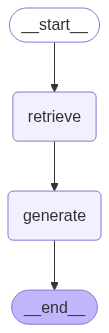

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
result = graph.invoke({"question": "Que asistencias tienes disponibles?"})

print(f'Context: {result["context"]}\n\n')
print(f'Answer: {result["answer"]}')

Context: [Document(metadata={'doc_id': '81b5ed29-219b-4029-9bff-71a06678efc5', 'sesion': '466_pp2016_2021_pa2018_2019_leg1_page_1', 'fecha_iso': '2018-09-06T09:15:00', 'fecha_ts': 1536243300000, 'anio': 2018, 'mes': 9, 'dia': 6, 'hora': '09:15', 'fecha_larga': '06 de septiembre del 2018', 'fecha_corta': '06 sep 2018', 'legislatura_txt': 'Sesión Extraordinaria 2018-2019', 'n_legislatura': 1, 'periodo_congreso_inicio': 2016, 'periodo_congreso_fin': 2021, 'periodo_anual_inicio': 2018, 'periodo_anual_fin': 2019, 'page': 1, 'url': 'http://localhost:8080/asistencia/466_pp2016_2021_pa2018_2019_leg1_page_1.png', 'doctype': 'attendance_header', 'version': '2025.09.01.16.03', '_id': '81b5ed29-219b-4029-9bff-71a06678efc5', '_collection_name': 'attendance_docs'}, page_content='Asistencia del 06 de septiembre del 2018 – Sesión Extraordinaria 2018-2019.\nCongreso 2016-2021 | Periodo anual 2018-2019.\nURL: http://localhost:8080/asistencia/466_pp2016_2021_pa2018_2019_leg1_page_1.png'), Document(metada

In [13]:
result = graph.invoke({"question": "Dame las asistencias de la tercera legislatura ordinaria 2020-2021"})

print(f'Context: {result["context"]}\n\n')
print(f'Answer: {result["answer"]}')

Context: [Document(metadata={'doc_id': '02e427cd-2608-41d1-8c76-c2e2fcb3ee44', 'sesion': '316_pp2016_2021_pa2021_2022_leg3_page_3', 'fecha_iso': '2021-03-11T11:25:00', 'fecha_ts': 1615479900000, 'anio': 2021, 'mes': 3, 'dia': 11, 'hora': '11:25', 'fecha_larga': '11 de marzo del 2021', 'fecha_corta': '11 mar 2021', 'legislatura_txt': 'Tercera Legislatura Ordinaria 2020-2021', 'n_legislatura': 3, 'periodo_congreso_inicio': 2016, 'periodo_congreso_fin': 2021, 'periodo_anual_inicio': 2021, 'periodo_anual_fin': 2022, 'page': 3, 'url': 'http://localhost:8080/asistencia/316_pp2016_2021_pa2021_2022_leg3_page_3.png', 'doctype': 'attendance_header', 'version': '2025.09.01.16.03', '_id': '02e427cd-2608-41d1-8c76-c2e2fcb3ee44', '_collection_name': 'attendance_docs'}, page_content='Asistencia del 11 de marzo del 2021 – Tercera Legislatura Ordinaria 2020-2021.\nCongreso 2016-2021 | Periodo anual 2021-2022.\nURL: http://localhost:8080/asistencia/316_pp2016_2021_pa2021_2022_leg3_page_3.png'), Document

In [14]:
result = graph.invoke({"question": "Dame las asistencias del 10 de octubre del 2024"})

print(f'Context: {result["context"]}\n\n')
print(f'Answer: {result["answer"]}')

Context: [Document(metadata={'doc_id': 'bd89d497-3f95-4d58-9d8a-4043306f61b5', 'sesion': '036_pp2021_2026_pa2024_2025_leg1_page_11', 'fecha_iso': '2024-10-11T22:09:00', 'fecha_ts': 1728702540000, 'anio': 2024, 'mes': 10, 'dia': 11, 'hora': '22:09', 'fecha_larga': '11 de octubre del 2024', 'fecha_corta': '11 oct 2024', 'legislatura_txt': 'Primera Legislatura Ordinaria 2024-2025', 'n_legislatura': 1, 'periodo_congreso_inicio': 2021, 'periodo_congreso_fin': 2026, 'periodo_anual_inicio': 2024, 'periodo_anual_fin': 2025, 'page': 11, 'url': 'http://localhost:8080/asistencia/036_pp2021_2026_pa2024_2025_leg1_page_11.png', 'doctype': 'attendance_header', 'version': '2025.09.01.16.03', '_id': 'bd89d497-3f95-4d58-9d8a-4043306f61b5', '_collection_name': 'attendance_docs'}, page_content='Asistencia del 11 de octubre del 2024 – Primera Legislatura Ordinaria 2024-2025.\nCongreso 2021-2026 | Periodo anual 2024-2025.\nURL: http://localhost:8080/asistencia/036_pp2021_2026_pa2024_2025_leg1_page_11.png'),